In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


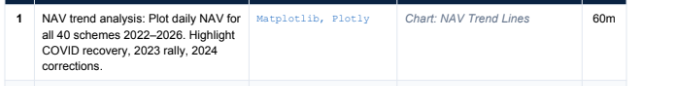

In [ ]:
nav = pd.read_csv("/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_nav.csv")
print(nav.shape)
print(nav.columns)
print(nav["amfi_code"].nunique())
print(nav["date"].dtypes)

(46000, 4)
Index(['Unnamed: 0', 'amfi_code', 'date', 'nav'], dtype='object')
40
object


In [ ]:
nav["date"] = pd.to_datetime(nav["date"])
print(nav["date"].dtypes)

datetime64[ns]


In [ ]:
print(nav.head())

   Unnamed: 0  amfi_code       date      nav
0           0     119551 2022-01-03  54.3856
1           1     119551 2022-01-04  54.3474
2           2     119551 2022-01-05  54.6869
3           3     119551 2022-01-06  55.4550
4           4     119551 2022-01-07  55.3692


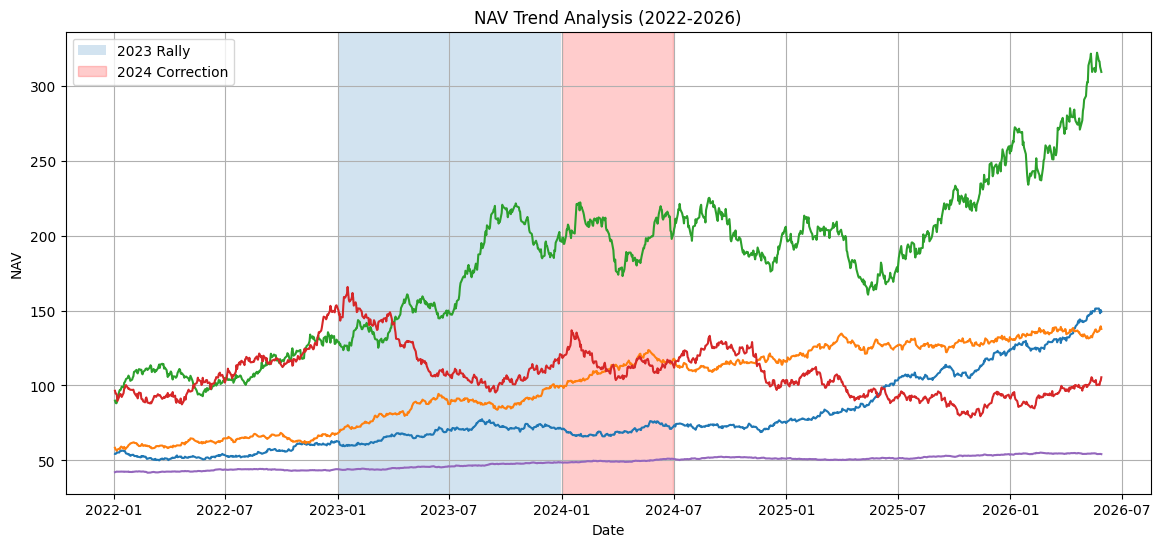

In [ ]:
top5 = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(14,6))

for code in top5:
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"])

# 2023 rally
plt.axvspan(
    pd.to_datetime("2023-01-01"),
    pd.to_datetime("2023-12-31"),
    alpha=0.2,
    label="2023 Rally"
)

# 2024 correction
plt.axvspan(
    pd.to_datetime("2024-01-01"),
    pd.to_datetime("2024-06-30"),
    alpha=0.2,
    color='red',
    label="2024 Correction"
)

plt.title("NAV Trend Analysis (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)


plt.savefig(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/nav_trend_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

observation from data set:
the dataset begin in january 2022. the observed nav trend represent the post covid recovery phase of mutual fund industary.

##        impotant information from this image:

      1. nav growth shows that value of per share or unit increase then wealth of investor also increases

      2. short term fluctuation are visible due to volatility. low volatility meaning more stable market

      3. equity-oriented schemes generaly show higher appreciation than debt-oriented schemes

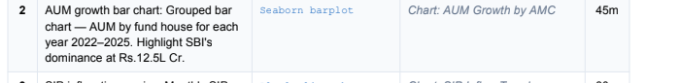

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/bluestock_mf_capstone/data/raw/03_aum_by_fund_house.csv")
df["date"] = pd.to_datetime(df["date"])
df.to_csv("/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_aum_by_fund_house.csv")
df.info()

NameError: name 'pd' is not defined

In [2]:
import pandas as pd

aum = pd.read_csv("/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_aum_by_fund_house.csv")
aum.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_aum_by_fund_house.csv'

In [ ]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

aum_yearly = (
    aum.groupby(["fund_house", "year"])["aum_crore"]
    .mean()
    .reset_index()
)

aum_yearly.head()

In [ ]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_crore",
    hue="year"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Fund House")
plt.ylabel("Average AUM (Crore ₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/aum_growth_by_amc.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

NameError: name 'plt' is not defined

Highlight SBI Dominance

In [ ]:
sbi = aum_yearly[aum_yearly["fund_house"].str.contains("SBI", case=False)]

print(sbi.sort_values("aum_crore", ascending=False).head())

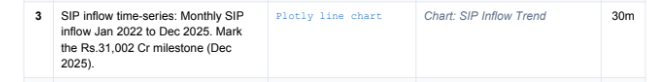

In [ ]:
import pandas as pd
import plotly.express as px

sip = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/04_monthly_sip_inflows.csv"
)

print(sip.columns)
print(sip.info())
sip.head()

In [ ]:
import pandas as pd
import plotly.express as px

# Load data
sip = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/04_monthly_sip_inflows.csv"
)

# Convert month column
sip["month"] = pd.to_datetime(sip["month"])

# Create line chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Highlight Dec 2025 milestone
fig.add_annotation(
    x=pd.Timestamp("2025-12-01"),
    y=31002,
    text="₹31,002 Cr Milestone (Dec 2025)",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white"
)
fig.write_html(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/sip_inflow_trend.html"
)

fig.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
cat = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/05_category_inflows.csv"
)

print(cat.columns)
cat.head()
print(cat.info())

Index(['month', 'category', 'net_inflow_crore'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    object 
 1   category          144 non-null    object 
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.5+ KB
None


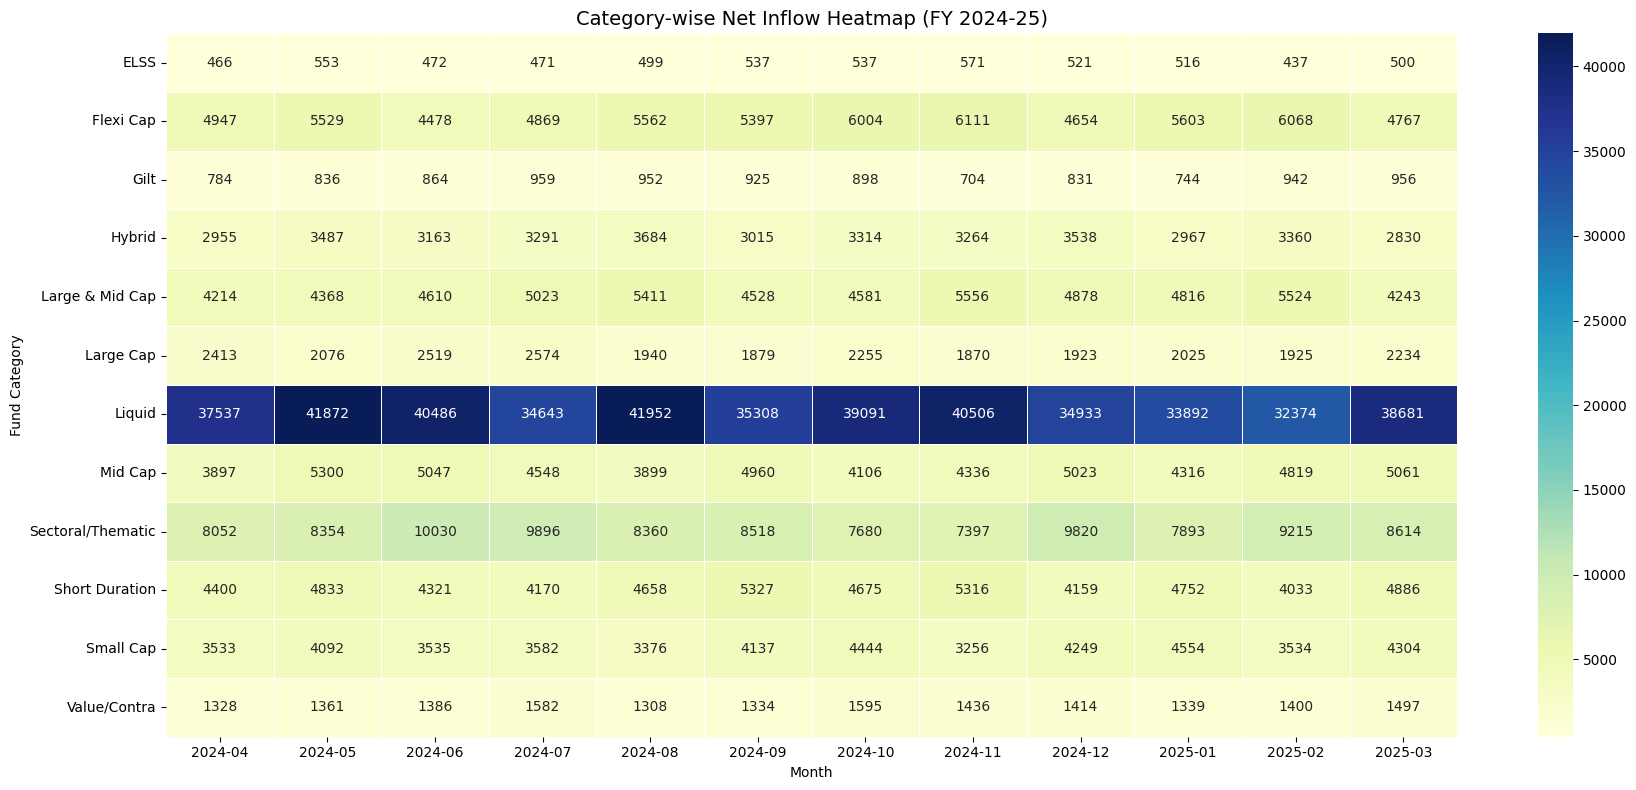

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
cat = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/05_category_inflows.csv"
)

# Create heatmap matrix
heatmap_data = cat.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Plot Heatmap
plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap (FY 2024-25)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

# Save chart
plt.savefig(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



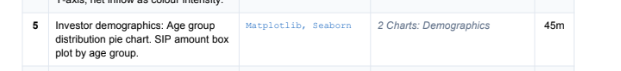

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tx = pd.read_csv("/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_transactions.csv")


print(tx.columns)
tx.head()

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


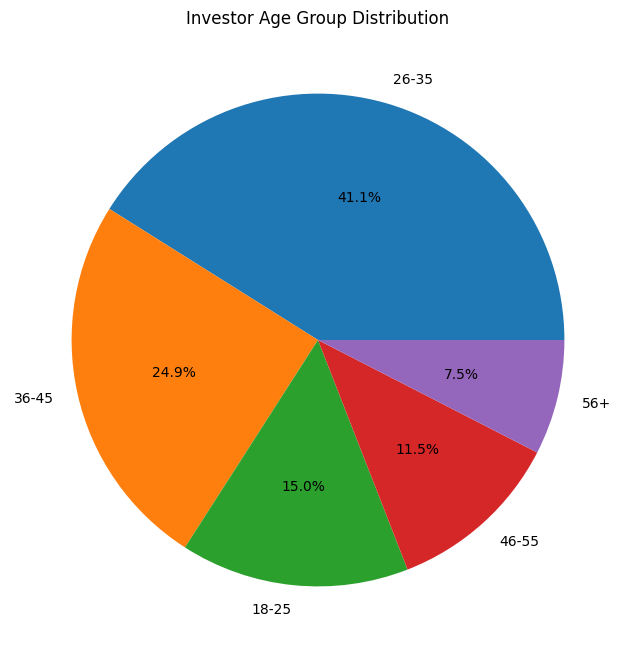

In [ ]:
age_counts = tx["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
sip_tx = tx[
    tx["transaction_type"] == "SIP"
]

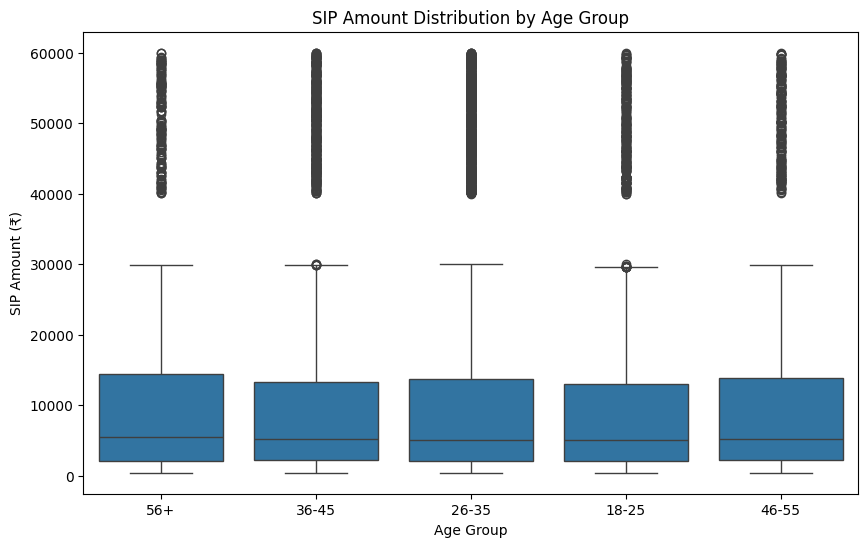

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_tx,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.savefig(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

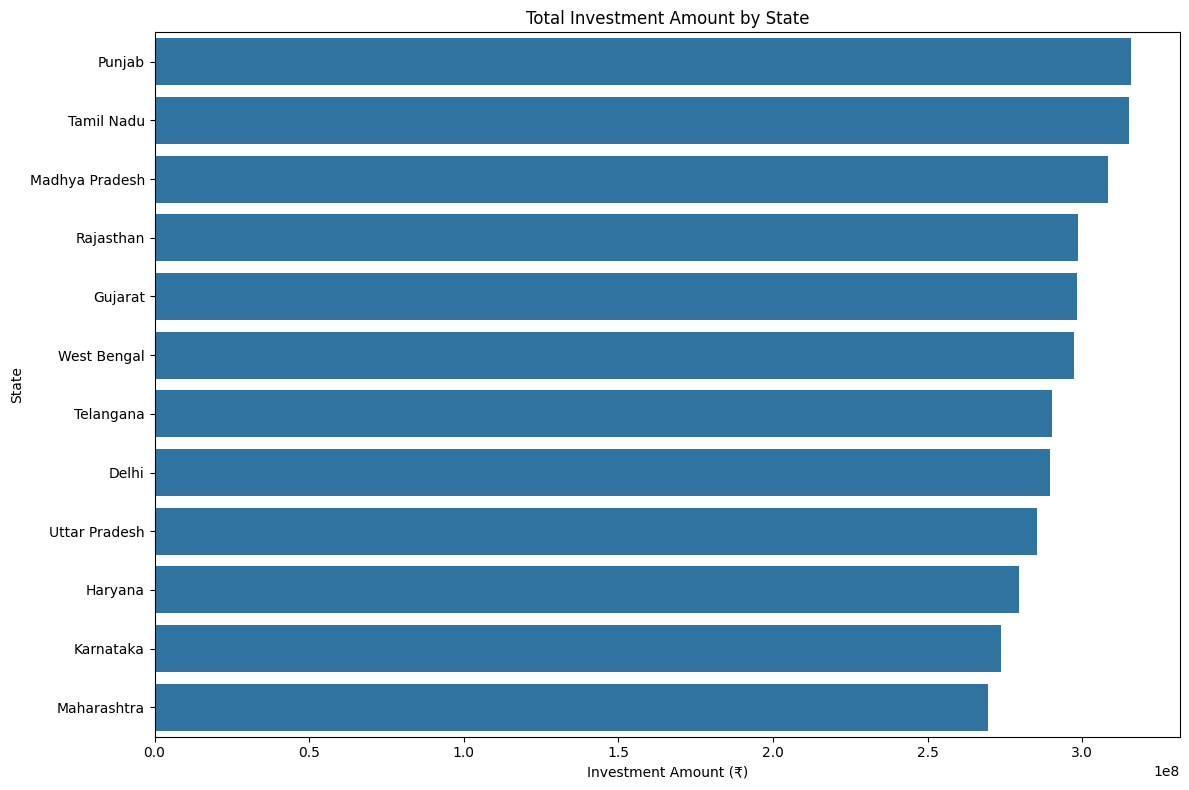

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
tx = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/08_investor_transactions.csv"
)

# =========================
# Chart 1: State-wise Investment
# =========================

state_investment = (
    tx.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_investment.values,
    y=state_investment.index
)

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/state_investment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



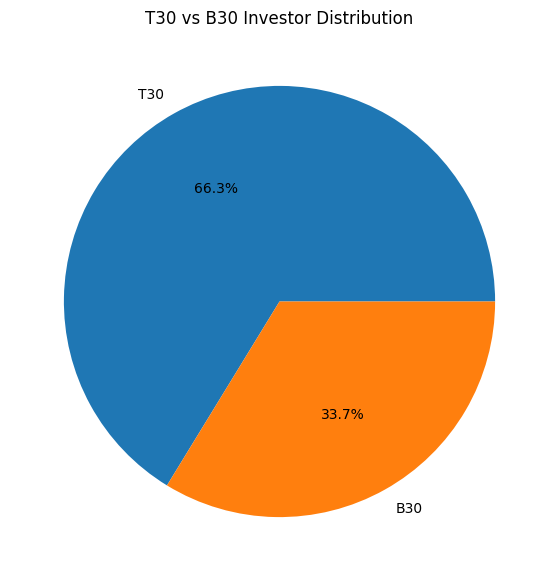

In [ ]:
# =========================
# Chart 2: T30 vs B30 Distribution
# =========================

tier_counts = tx["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [ ]:
folio = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/06_industry_folio_count.csv"
)

print(folio.head())
print(folio.columns)
print(folio.info())

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column        

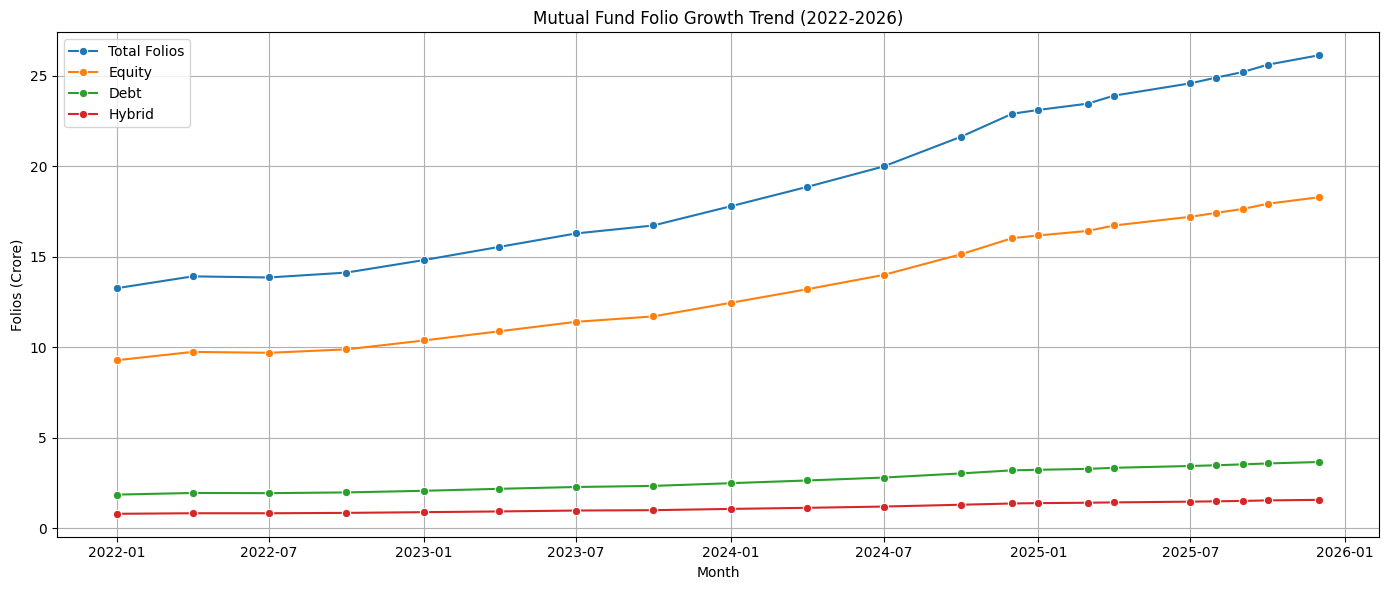

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
folio = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/06_industry_folio_count.csv"
)

# Convert month column
folio["month"] = pd.to_datetime(folio["month"])

# Plot folio growth trends
plt.figure(figsize=(14,6))

sns.lineplot(
    data=folio,
    x="month",
    y="total_folios_crore",
    marker="o",
    label="Total Folios"
)

sns.lineplot(
    data=folio,
    x="month",
    y="equity_folios_crore",
    marker="o",
    label="Equity"
)

sns.lineplot(
    data=folio,
    x="month",
    y="debt_folios_crore",
    marker="o",
    label="Debt"
)

sns.lineplot(
    data=folio,
    x="month",
    y="hybrid_folios_crore",
    marker="o",
    label="Hybrid"
)

plt.title("Mutual Fund Folio Growth Trend (2022-2026)")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.grid(True)

plt.tight_layout()

# Save chart
plt.savefig(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



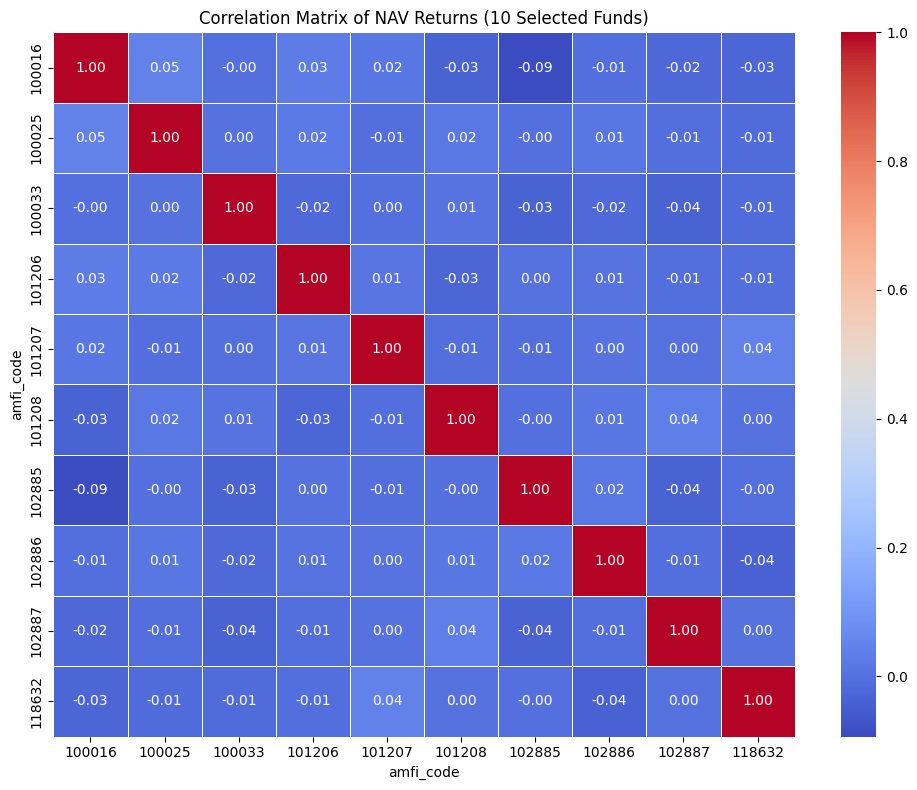

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load NAV data
nav = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_nav.csv"
)

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Sort values
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

# Select first 10 funds
selected_funds = nav["amfi_code"].unique()[:10]

nav_10 = nav[
    nav["amfi_code"].isin(selected_funds)
]

# Create return matrix
return_matrix = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

# Compute correlation matrix
corr_matrix = return_matrix.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of NAV Returns (10 Selected Funds)")

plt.tight_layout()

# Save chart
plt.savefig(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

holdings = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/09_portfolio_holdings.csv"
)

print(holdings.columns)
holdings.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


       sector  weight_pct
0     Banking      652.26
1          IT      455.47
2      Pharma      407.45
3  Automobile      323.65
4   Utilities      265.54


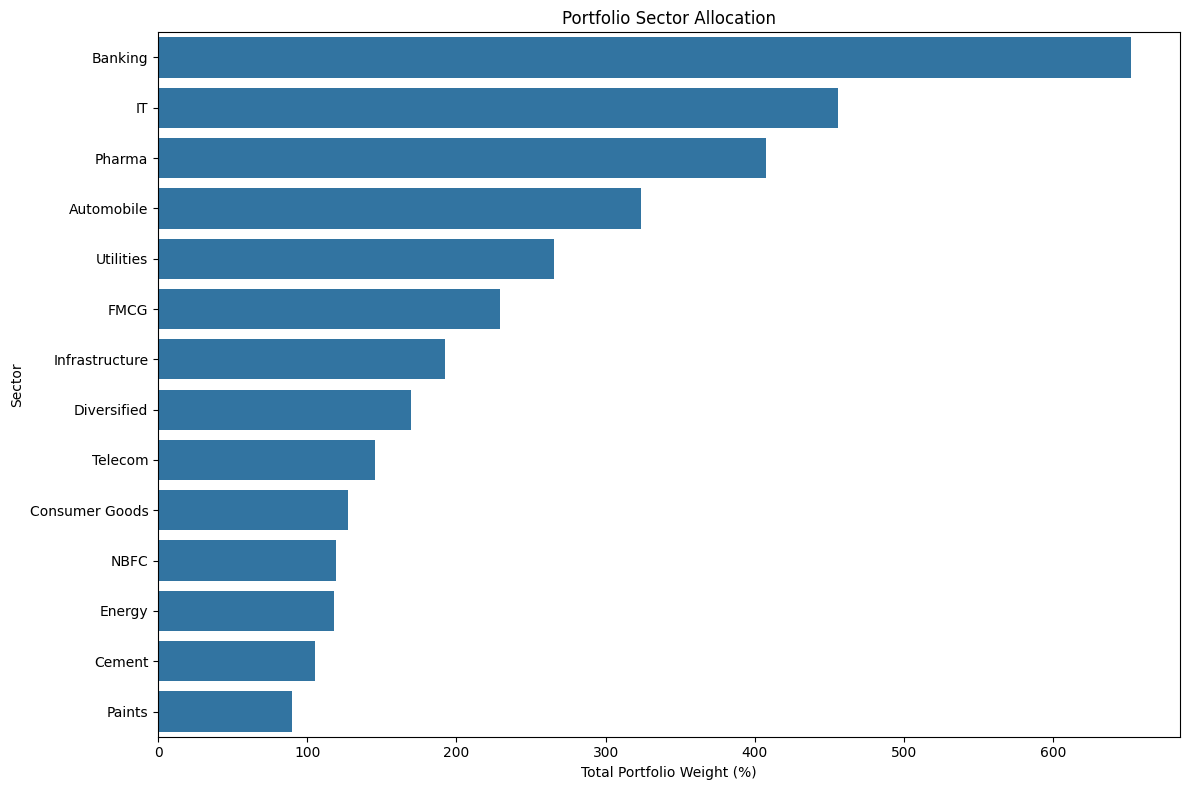

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
holdings = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/09_portfolio_holdings.csv"
)

# Aggregate sector allocation
sector_alloc = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(sector_alloc.head())

# Plot chart
plt.figure(figsize=(12,8))

sns.barplot(
    data=sector_alloc,
    x="weight_pct",
    y="sector"
)

plt.title("Portfolio Sector Allocation")
plt.xlabel("Total Portfolio Weight (%)")
plt.ylabel("Sector")

plt.tight_layout()

# Save chart
plt.savefig(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# Exploratory Data Analysis (EDA) Summary Report

## Project Overview

Exploratory Data Analysis was performed on the mutual fund datasets to identify trends, patterns, and business insights related to fund performance, investor behavior, industry growth, and portfolio composition.

---

## 1. NAV Trend Analysis

* Most mutual fund schemes showed a positive long-term NAV trend between 2022 and 2026.
* Strong growth was observed during the 2023 market rally.
* Temporary corrections were visible during parts of 2024.
* Overall, mutual funds demonstrated strong wealth creation potential over the analysis period.

---

## 2. AUM Growth Analysis

* Assets Under Management (AUM) increased consistently across major fund houses.
* SBI Mutual Fund maintained the highest AUM among all AMCs.
* HDFC Mutual Fund and ICICI Prudential Mutual Fund also recorded significant growth.
* The industry experienced steady expansion during the study period.

---

## 3. SIP Inflow Analysis

* Monthly SIP inflows increased steadily from 2022 to 2025.
* Investor participation continued to rise throughout the period.
* SIP inflows reached a record ₹31,002 crore in December 2025.
* The results indicate increasing investor confidence in mutual fund investments.

---

## 4. Category-wise Inflow Analysis

* Equity-oriented categories received the highest net inflows.
* Large Cap, Mid Cap, and Small Cap funds remained popular investment choices.
* Investor preferences varied across market conditions and fund categories.

---

## 5. Investor Demographics Analysis

* Most investors belonged to the 26–35 and 36–45 age groups.
* Working-age investors represented the largest share of mutual fund participants.
* SIP contribution levels differed across age groups, reflecting varying income levels and investment capacity.

---

## 6. Geographic Distribution Analysis

* Maharashtra, Delhi, Karnataka, and Tamil Nadu contributed significant investment volumes.
* T30 cities accounted for the majority of investments.
* B30 cities also showed growing participation, indicating increasing financial awareness across India.

---

## 7. Folio Growth Analysis

* Total mutual fund folios increased consistently over time.
* Equity folios contributed the largest share of growth.
* Rising folio counts indicate growing retail investor participation.

---

## 8. Correlation Analysis

* Most selected mutual funds exhibited positive return correlations.
* Highly correlated funds tended to move together during market fluctuations.
* Lower-correlated funds may provide diversification benefits to investors.

---

## 9. Portfolio Sector Allocation Analysis

* Banking emerged as one of the most heavily allocated sectors.
* Significant allocations were also observed in Pharma, IT, Utilities, and Consumer sectors.
* Sector diversification reduced portfolio concentration risk.

---

## Overall Conclusion

The Indian mutual fund industry demonstrated strong growth across all major indicators, including NAV performance, AUM expansion, SIP inflows, and investor participation. Equity-oriented funds remained the preferred investment choice, while increasing folio counts and SIP contributions reflected growing investor confidence. The analysis highlights a healthy and expanding mutual fund ecosystem with strong long-term growth potential.
